## Data from World Happiness Report

The World Happiness Report is an annual publication of the United Nations Sustainable Development Solutions Network. It contains articles, and rankings of national happiness based on respondent ratings of their own lives, which the report also correlates with various life factors.

In this notebook we will explore the happiness of different countries and the features associated.
The datasets that we will use are available in *Data*: **happiness2020.pkl** and **countries_info.csv**.

Although the features are self-explanatory, here a summary: 

**happiness2020.pkl**
* country: *Name of the country*
* happiness_score: *Happiness score*
* social_support: *Social support (mitigation the effects of inequality)*
* healthy_life_expectancy: *Healthy Life Expectancy*
* freedom_of_choices: *Freedom to make life choices*
* generosity: *Generosity (charity, volunteers)*
* perception_of_corruption: *Corruption Perception*
* world_region: *Area of the world of the country*

**countries_info.csv**
* country_name: *Name of the country*
* area: *Area in sq mi*
* population: *Number of people*
* literacy: *Literacy percentage*

In [2]:
!head Data/countries_info.csv

'head' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


In [3]:
import pandas as pd
%matplotlib inline

DATA_FOLDER = 'Data/'

HAPPINESS_DATASET = DATA_FOLDER+"happiness2020.csv"
COUNTRIES_DATASET = DATA_FOLDER+"countries_info.csv"

## Task 1: Load the data

Load the 2 datasets in Pandas dataframes (called *happiness* and *countries*), and show the first rows.


**Hint**: Use the correct reader and verify the data has the expected format.

In [35]:
# Write your code here
df_happy = pd.read_csv(HAPPINESS_DATASET)
df_country = pd.read_csv(COUNTRIES_DATASET)
df_happy.head(5)
df_country.head(5)

,country_name,area,population,literacy
0,afghanistan,647500,31056997,"36,0"
1,albania,28748,3581655,"86,5"
2,algeria,2381740,32930091,"70,0"
3,argentina,2766890,39921833,"97,1"
4,armenia,29800,2976372,"98,6"


## Task 2: Let's merge the data

Create a dataframe called *country_features* by merging *happiness* and *countries*. A row of this dataframe must describe all the features that we have about a country.

**Hint**: Verify that all the rows are in the final dataframe.

In [36]:
# Write your code here
df_happy["country_merge"] = df_happy["country"].str.strip().str.lower() #make a new colomn country_merge with lowercase things.
df_country["country_merge"] = df_country["country_name"].str.strip().str.lower()
country_features = pd.merge(df_happy, df_country, on="country_merge")
country_features = country_features.drop(columns=["country", "country_name"])
country_features = country_features.rename(columns={"country_merge": "country"})
country_features.describe

<bound method NDFrame.describe of      happiness_score  social_support  healthy_life_expectancy  \
0             2.5669        0.470367                52.590000   
1             4.8827        0.671070                68.708138   
2             5.0051        0.803385                65.905174   
3             5.9747        0.900568                68.803802   
4             4.6768        0.757479                66.750656   
..               ...             ...                      ...   
130           5.0532        0.890408                66.505341   
131           5.3535        0.849987                67.952736   
132           3.5274        0.817981                56.727283   
133           3.7594        0.698824                55.299377   
134           3.2992        0.763093                55.617260   

     freedom_of_choices  generosity  perception_of_corruption  \
0              0.396573   -0.096429                  0.933687   
1              0.781994   -0.042309                  0.

## Task 3: Where are people happier?

Print the top 10 countries based on their happiness score (higher is better).

In [41]:
# Write your code here
happy_countries = country_features.sort_values("happiness_score", ascending=False)
happy_countries["country"].head(10)

38         finland
31         denmark
115    switzerland
50         iceland
92          norway
87     netherlands
114         sweden
88     new zealand
6          austria
72      luxembourg
Name: country, dtype: str

We are interested to know in what world region people are happier. 

Create and print a dataframe with the (1) average happiness score and (2) the number of contries for each world region.
Sort the result to show the happiness ranking.

In [ ]:
# Write your code here
region_happiness = (
    country_features
    .groupby("world_region")
    .agg(
        average_happy=("happiness_score","mean"), 
        number_of_countries=("country", "count")
        )
    .sort_values("average_happy", ascending=False)
    )
print(region_happiness)

                                    average_happy  number_of_countries
world_region                                                          
North America and ANZ                    7.173525                    4
Western Europe                           6.967405                   20
Latin America and Caribbean              5.971280                   20
Central and Eastern Europe               5.891393                   14
Southeast Asia                           5.517788                    8
East Asia                                5.483633                    3
Commonwealth of Independent States       5.358342                   12
Middle East and North Africa             5.269306                   16
Sub-Saharan Africa                       4.393856                   32
South Asia                               4.355083                    6


The first region has only a few countries! What are them and what is their score?

In [56]:
# Write your code here
only_na = country_features[(country_features["world_region"] == "North America and ANZ")]
only_na = only_na[["country","happiness_score"]]
print(only_na)

           country  happiness_score
5        australia           7.2228
21          canada           7.2321
88     new zealand           7.2996
127  united states           6.9396


## Task 4: How literate is the world?

Print the names of the countries with a level of literacy of 100%. 

For each country, print the name and the world region in the format: *{region name} - {country name} ({happiness score})*

In [63]:
# Write your code here
good_literacy = country_features[(country_features["literacy"] == "100,0")]
good_literacy.shape # to check that i have something
good_literacy = good_literacy[["world_region", "country", "happiness_score"]]
print(good_literacy)

             world_region     country  happiness_score
5   North America and ANZ   australia           7.2228
31         Western Europe     denmark           7.6456
38         Western Europe     finland           7.8087
72         Western Europe  luxembourg           7.2375
92         Western Europe      norway           7.4880


What is the global average?

In [69]:
# Write your code here
average = (pd.to_numeric(country_features["literacy"].str.replace(",","."), errors="coerce")).mean()
print(average)

81.85112781954888


Calculate the proportion of countries with a literacy level below 50%. Print the value in percentage, formatted with 2 decimals.

In [89]:
# Write your code here
numeric_literacy = country_features[["literacy"]]
# print(numeric_literacy)
number_of_countries = numeric_literacy.count()
number_of_countries_under_50 = numeric_literacy[(numeric_literacy["literacy"]< 50)].count()
proportion = number_of_countries_under_50 / number_of_countries * 100
print(proportion)
print(f"{proportion.item():.2f}")

literacy    12.030075
dtype: float64
12.03


Print the raw number and the percentage of world population that is illiterate.

In [105]:
# Write your code here
country_features.head()
total_population = country_features["population"].sum()
# print(total_population)

literate_population = country_features["population"]*country_features["literacy"]
literate_population_number = literate_population.sum()/100
# print(literate_population_number)
illeterate_pop_number = total_population - literate_population_number

print(illeterate_pop_number)
percentage = illeterate_pop_number / total_population * 100
print(percentage)


1256862990.1029997
20.4518441527569


## Task 5: Population density

Add to the dataframe a new field called *population_density* computed by dividing *population* by *area*.

In [106]:
# Write your code here
country_features["population_density"] = country_features["population"] / country_features["area"]

What is the happiness score of the 3 countries with the lowest population density?

In [108]:
# Write your code here
country_features.sort_values("population_density", ascending=True)
country_features["happiness_score"].head(3)

0    2.5669
1    4.8827
2    5.0051
Name: happiness_score, dtype: float64

## Task 6: Healty and happy?

Plot in a scatter plot the happiness score (x) and healty life expectancy (y).

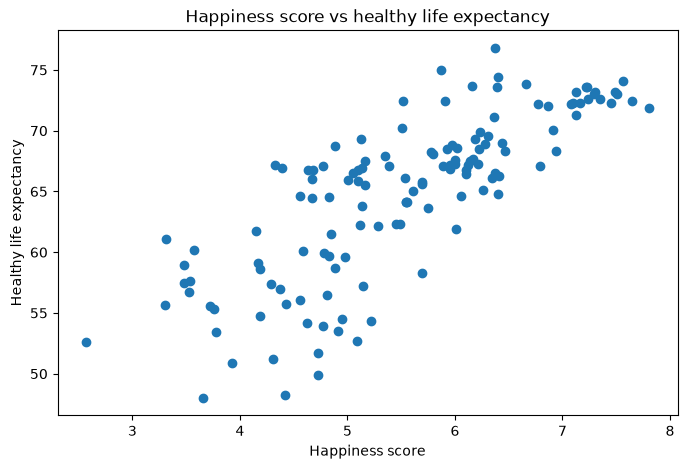

In [110]:
# Write your code here
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.scatter(
    country_features["happiness_score"],   # x values
    country_features["healthy_life_expectancy"]  # y values
)

plt.xlabel("Happiness score")
plt.ylabel("Healthy life expectancy")
plt.title("Happiness score vs healthy life expectancy")

plt.show()

Feel free to continue the exploration of the dataset! We'll release the solutions next week.

----
Enjoy EPFL and be happy, next year Switzerland must be #1.